# Hackathon ML — Morpion & IA
**ISPM — Master 1 · Machine Learning**

Ce notebook couvre :
- **Étape 1** — EDA et Préparation des Données
- **Étape 2** — Baseline : Régression Logistique (x_wins & is_draw)
- **Étape 3** — Modèles Avancés (Decision Tree, Random Forest, Gradient Boosting, MLP)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    accuracy_score, f1_score, confusion_matrix, classification_report,
    roc_auc_score, ConfusionMatrixDisplay
)
from sklearn.preprocessing import StandardScaler
import joblib
import os

# Style global
sns.set_theme(style='darkgrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
print(' Imports OK')

ModuleNotFoundError: No module named 'pandas'

---
##  Étape 1 — EDA et Préparation des Données

In [ ]:
# ── Chargement du dataset
df = pd.read_csv('ressources/dataset.csv')
print(f'Shape : {df.shape}')
print(f'Colonnes : {list(df.columns)}')
df.head()

Shape : (2423, 20)
Colonnes : ['c0_x', 'c0_o', 'c1_x', 'c1_o', 'c2_x', 'c2_o', 'c3_x', 'c3_o', 'c4_x', 'c4_o', 'c5_x', 'c5_o', 'c6_x', 'c6_o', 'c7_x', 'c7_o', 'c8_x', 'c8_o', 'x_wins', 'is_draw']


,c0_x,c0_o,c1_x,c1_o,c2_x,c2_o,c3_x,c3_o,c4_x,c4_o,c5_x,c5_o,c6_x,c6_o,c7_x,c7_o,c8_x,c8_o,x_wins,is_draw
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1
1,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0
2,1,0,0,1,1,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0
3,1,0,0,1,1,0,0,1,1,0,0,1,0,0,0,0,0,0,1,0
4,1,0,0,1,1,0,0,1,1,0,0,1,0,1,1,0,0,0,1,0


In [ ]:
# ── Infos générales
print('=== Info ===')
df.info()
print('\n=== Statistiques descriptives ===')
df.describe()

=== Info ===
<class 'pandas.DataFrame'>
RangeIndex: 2423 entries, 0 to 2422
Data columns (total 20 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   c0_x     2423 non-null   int64
 1   c0_o     2423 non-null   int64
 2   c1_x     2423 non-null   int64
 3   c1_o     2423 non-null   int64
 4   c2_x     2423 non-null   int64
 5   c2_o     2423 non-null   int64
 6   c3_x     2423 non-null   int64
 7   c3_o     2423 non-null   int64
 8   c4_x     2423 non-null   int64
 9   c4_o     2423 non-null   int64
 10  c5_x     2423 non-null   int64
 11  c5_o     2423 non-null   int64
 12  c6_x     2423 non-null   int64
 13  c6_o     2423 non-null   int64
 14  c7_x     2423 non-null   int64
 15  c7_o     2423 non-null   int64
 16  c8_x     2423 non-null   int64
 17  c8_o     2423 non-null   int64
 18  x_wins   2423 non-null   int64
 19  is_draw  2423 non-null   int64
dtypes: int64(20)
memory usage: 378.7 KB

=== Statistiques descriptives ===


,c0_x,c0_o,c1_x,c1_o,c2_x,c2_o,c3_x,c3_o,c4_x,c4_o,c5_x,c5_o,c6_x,c6_o,c7_x,c7_o,c8_x,c8_o,x_wins,is_draw
count,2423.000000,2423.000000,2423.000000,2423.000000,2423.000000,2423.000000,2423.000000,2423.000000,2423.000000,2423.000000,2423.000000,2423.000000,2423.000000,2423.000000,2423.000000,2423.000000,2423.000000,2423.000000,2423.000000,2423.000000
mean,0.300041,0.300041,0.306232,0.306232,0.300041,0.300041,0.306232,0.306232,0.293851,0.293851,0.306232,0.306232,0.300041,0.300041,0.306232,0.306232,0.300041,0.300041,0.755262,0.182006
std,0.458370,0.458370,0.461022,0.461022,0.458370,0.458370,0.461022,0.461022,0.455618,0.455618,0.461022,0.461022,0.458370,0.458370,0.461022,0.461022,0.458370,0.458370,0.430020,0.385929
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
75%,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [ ]:
# ── Vérification des valeurs manquantes
print('Valeurs manquantes par colonne :')
print(df.isnull().sum())
print(f'\nTotal NaN : {df.isnull().sum().sum()}')

Valeurs manquantes par colonne :
c0_x       0
c0_o       0
c1_x       0
c1_o       0
c2_x       0
c2_o       0
c3_x       0
c3_o       0
c4_x       0
c4_o       0
c5_x       0
c5_o       0
c6_x       0
c6_o       0
c7_x       0
c7_o       0
c8_x       0
c8_o       0
x_wins     0
is_draw    0
dtype: int64

Total NaN : 0


### 1.1 Distribution de x_wins et is_draw — Déséquilibre des classes ?

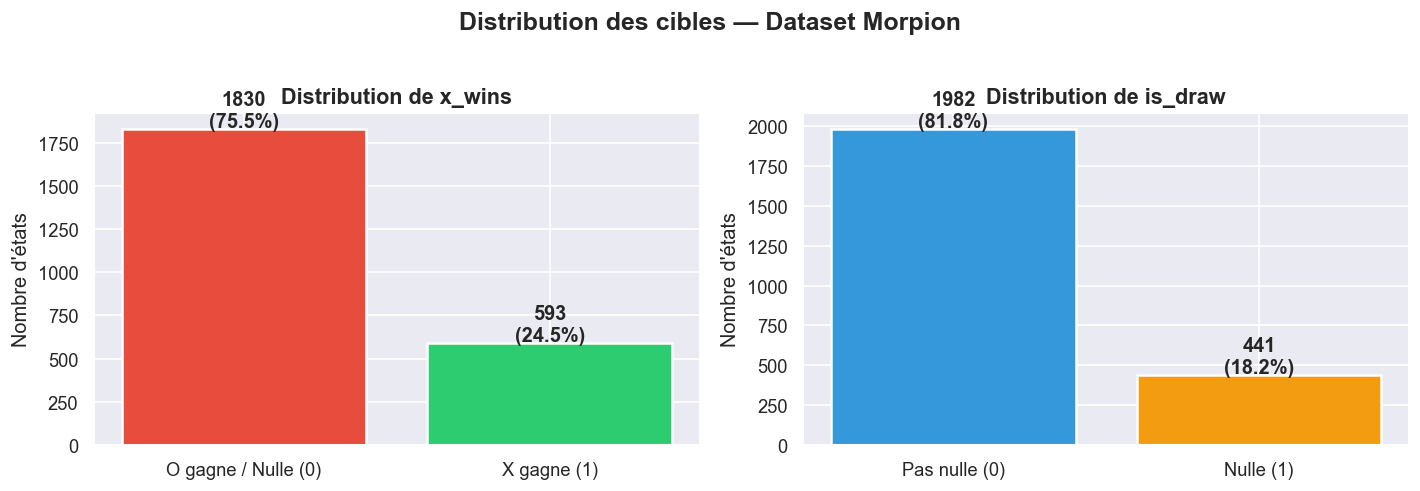


Ratio x_wins  : 3.09 (1 = X gagne)
Ratio is_draw : 0.22 (1 = nulle)


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# --- x_wins ---
counts_xw = df['x_wins'].value_counts()
axes[0].bar(['O gagne / Nulle (0)', 'X gagne (1)'], counts_xw.values,
            color=['#e74c3c', '#2ecc71'], edgecolor='white', linewidth=1.5)
axes[0].set_title('Distribution de x_wins', fontweight='bold', fontsize=13)
axes[0].set_ylabel('Nombre d\'états')
for i, v in enumerate(counts_xw.values):
    axes[0].text(i, v + 10, f'{v}\n({v/len(df)*100:.1f}%)', ha='center', fontweight='bold')

# --- is_draw ---
counts_id = df['is_draw'].value_counts()
axes[1].bar(['Pas nulle (0)', 'Nulle (1)'], counts_id.values,
            color=['#3498db', '#f39c12'], edgecolor='white', linewidth=1.5)
axes[1].set_title('Distribution de is_draw', fontweight='bold', fontsize=13)
axes[1].set_ylabel('Nombre d\'états')
for i, v in enumerate(counts_id.values):
    axes[1].text(i, v + 10, f'{v}\n({v/len(df)*100:.1f}%)', ha='center', fontweight='bold')

plt.suptitle('Distribution des cibles — Dataset Morpion', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('ressources/distribution_cibles.png', bbox_inches='tight', dpi=150)
plt.show()

print(f"\nRatio x_wins  : {counts_xw[1]/counts_xw[0]:.2f} (1 = X gagne)")
print(f"Ratio is_draw : {counts_id.get(1,0)/counts_id.get(0,1):.2f} (1 = nulle)")

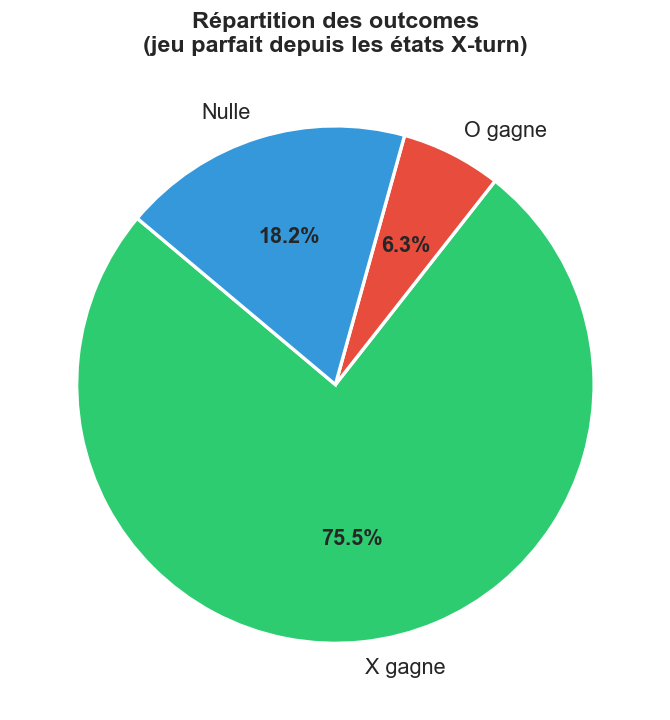

  X gagne : 1830 états (75.5%)
  O gagne : 152 états (6.3%)
  Nulle : 441 états (18.2%)


In [ ]:
# ── Répartition des 3 outcomes (X gagne / O gagne / Nulle)
x_wins_mask  = df['x_wins'] == 1
draw_mask    = df['is_draw'] == 1
o_wins_mask  = (df['x_wins'] == 0) & (df['is_draw'] == 0)

labels  = ['X gagne', 'O gagne', 'Nulle']
sizes   = [x_wins_mask.sum(), o_wins_mask.sum(), draw_mask.sum()]
colors  = ['#2ecc71', '#e74c3c', '#3498db']

fig, ax = plt.subplots(figsize=(7, 7))
wedges, texts, autotexts = ax.pie(
    sizes, labels=labels, autopct='%1.1f%%', colors=colors,
    startangle=140, wedgeprops=dict(edgecolor='white', linewidth=2),
    textprops=dict(fontsize=13)
)
for at in autotexts: at.set_fontweight('bold')
ax.set_title('Répartition des outcomes\n(jeu parfait depuis les états X-turn)', fontsize=14, fontweight='bold')
plt.savefig('ressources/pie_outcomes.png', bbox_inches='tight', dpi=150)
plt.show()

for l, s in zip(labels, sizes):
    print(f"  {l} : {s} états ({s/sum(sizes)*100:.1f}%)")

### 1.2 Quelle case est le plus souvent occupée par X dans les états où il gagne ?

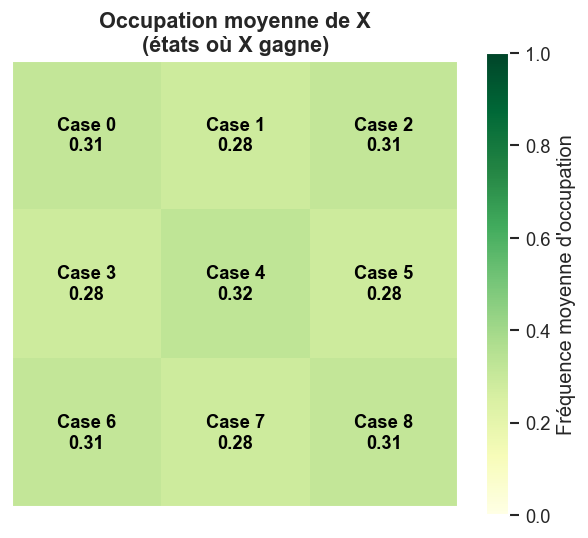

Cases les plus jouées par X quand il gagne :
Case 4    0.323497
Case 0    0.310929
Case 2    0.310929
Case 8    0.310929
Case 6    0.310929
Case 3    0.284699
Case 1    0.284699
Case 5    0.284699
Case 7    0.284699


In [ ]:
df_xwins = df[df['x_wins'] == 1]

# Occupation de X case par case (colonnes c{i}_x)
x_cols = [f'c{i}_x' for i in range(9)]
occ_x  = df_xwins[x_cols].mean().values.reshape(3, 3)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(occ_x, cmap='YlGn', vmin=0, vmax=1)
plt.colorbar(im, ax=ax, label='Fréquence moyenne d\'occupation')

positions = [(0,0),(0,1),(0,2),(1,0),(1,1),(1,2),(2,0),(2,1),(2,2)]
case_nums = [0,1,2,3,4,5,6,7,8]
for (r,c), n in zip(positions, case_nums):
    ax.text(c, r, f'Case {n}\n{occ_x[r,c]:.2f}', ha='center', va='center',
            fontsize=11, fontweight='bold',
            color='white' if occ_x[r,c] > 0.55 else 'black')

ax.set_xticks([]); ax.set_yticks([])
ax.set_title('Occupation moyenne de X\n(états où X gagne)', fontsize=13, fontweight='bold')
plt.savefig('ressources/heatmap_x_occupation.png', bbox_inches='tight', dpi=150)
plt.show()

print('Cases les plus jouées par X quand il gagne :')
occ_series = pd.Series(occ_x.flatten(), index=[f'Case {i}' for i in range(9)])
print(occ_series.sort_values(ascending=False).to_string())

### 1.3 Corrélation features ↔ cibles — Heatmap

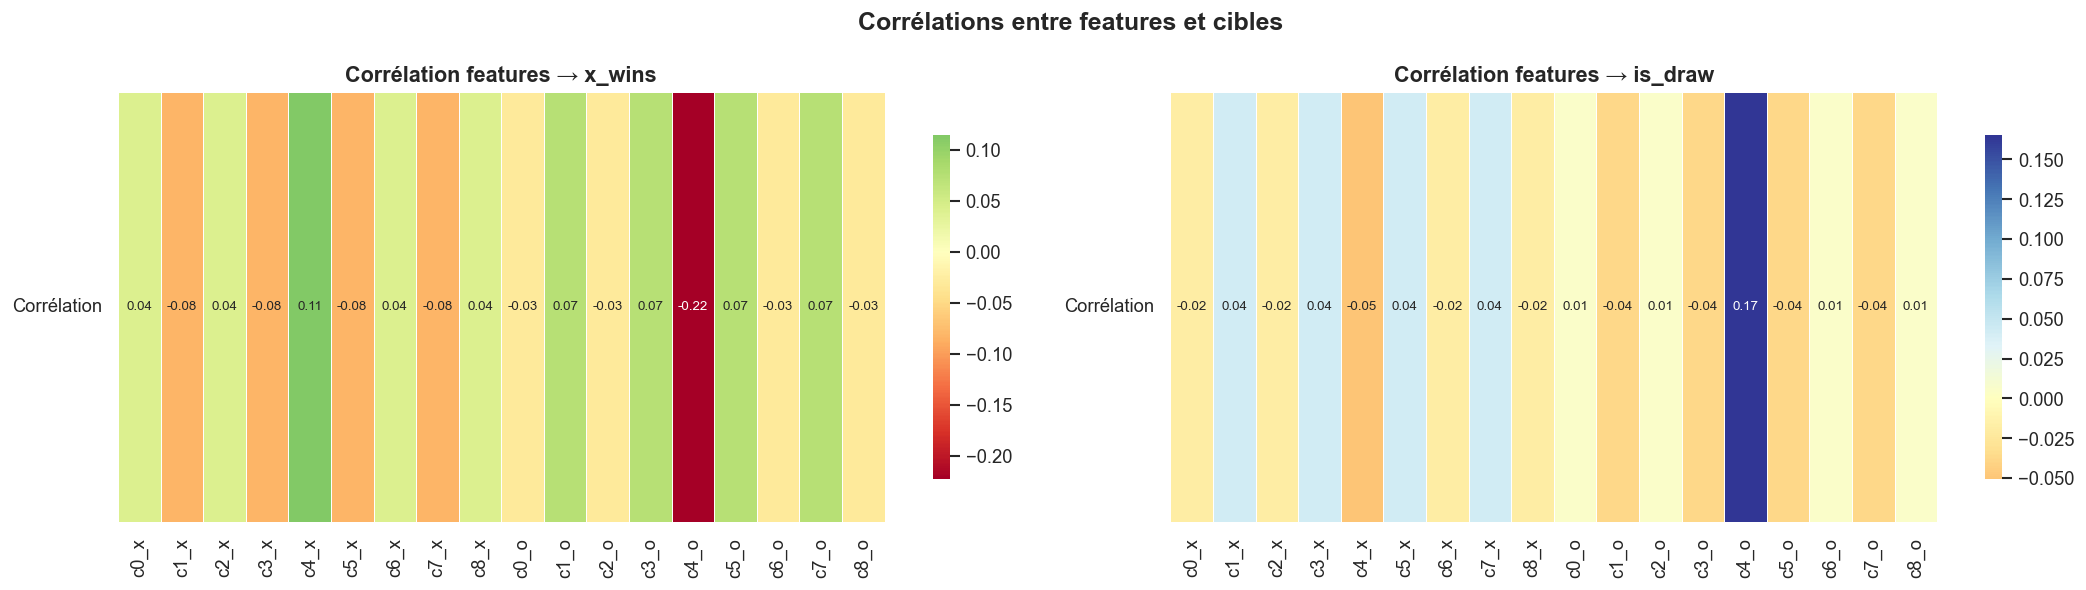

In [ ]:
feature_cols = [f'c{i}_x' for i in range(9)] + [f'c{i}_o' for i in range(9)]

corr_xwins = df[feature_cols].corrwith(df['x_wins'])
corr_draw  = df[feature_cols].corrwith(df['is_draw'])

fig, axes = plt.subplots(1, 2, figsize=(18, 5))

for ax, corr, title, cmap in [
    (axes[0], corr_xwins, 'Corrélation features → x_wins', 'RdYlGn'),
    (axes[1], corr_draw,  'Corrélation features → is_draw', 'RdYlBu')
]:
    corr_matrix = corr.values.reshape(1, -1)
    sns.heatmap(
        pd.DataFrame(corr_matrix, columns=feature_cols),
        ax=ax, cmap=cmap, center=0,
        annot=True, fmt='.2f', linewidths=0.5,
        annot_kws={'size': 8}, cbar_kws={'shrink': 0.8}
    )
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_yticklabels(['Corrélation'], rotation=0)

plt.suptitle('Corrélations entre features et cibles', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('ressources/heatmap_correlation.png', bbox_inches='tight', dpi=150)
plt.show()

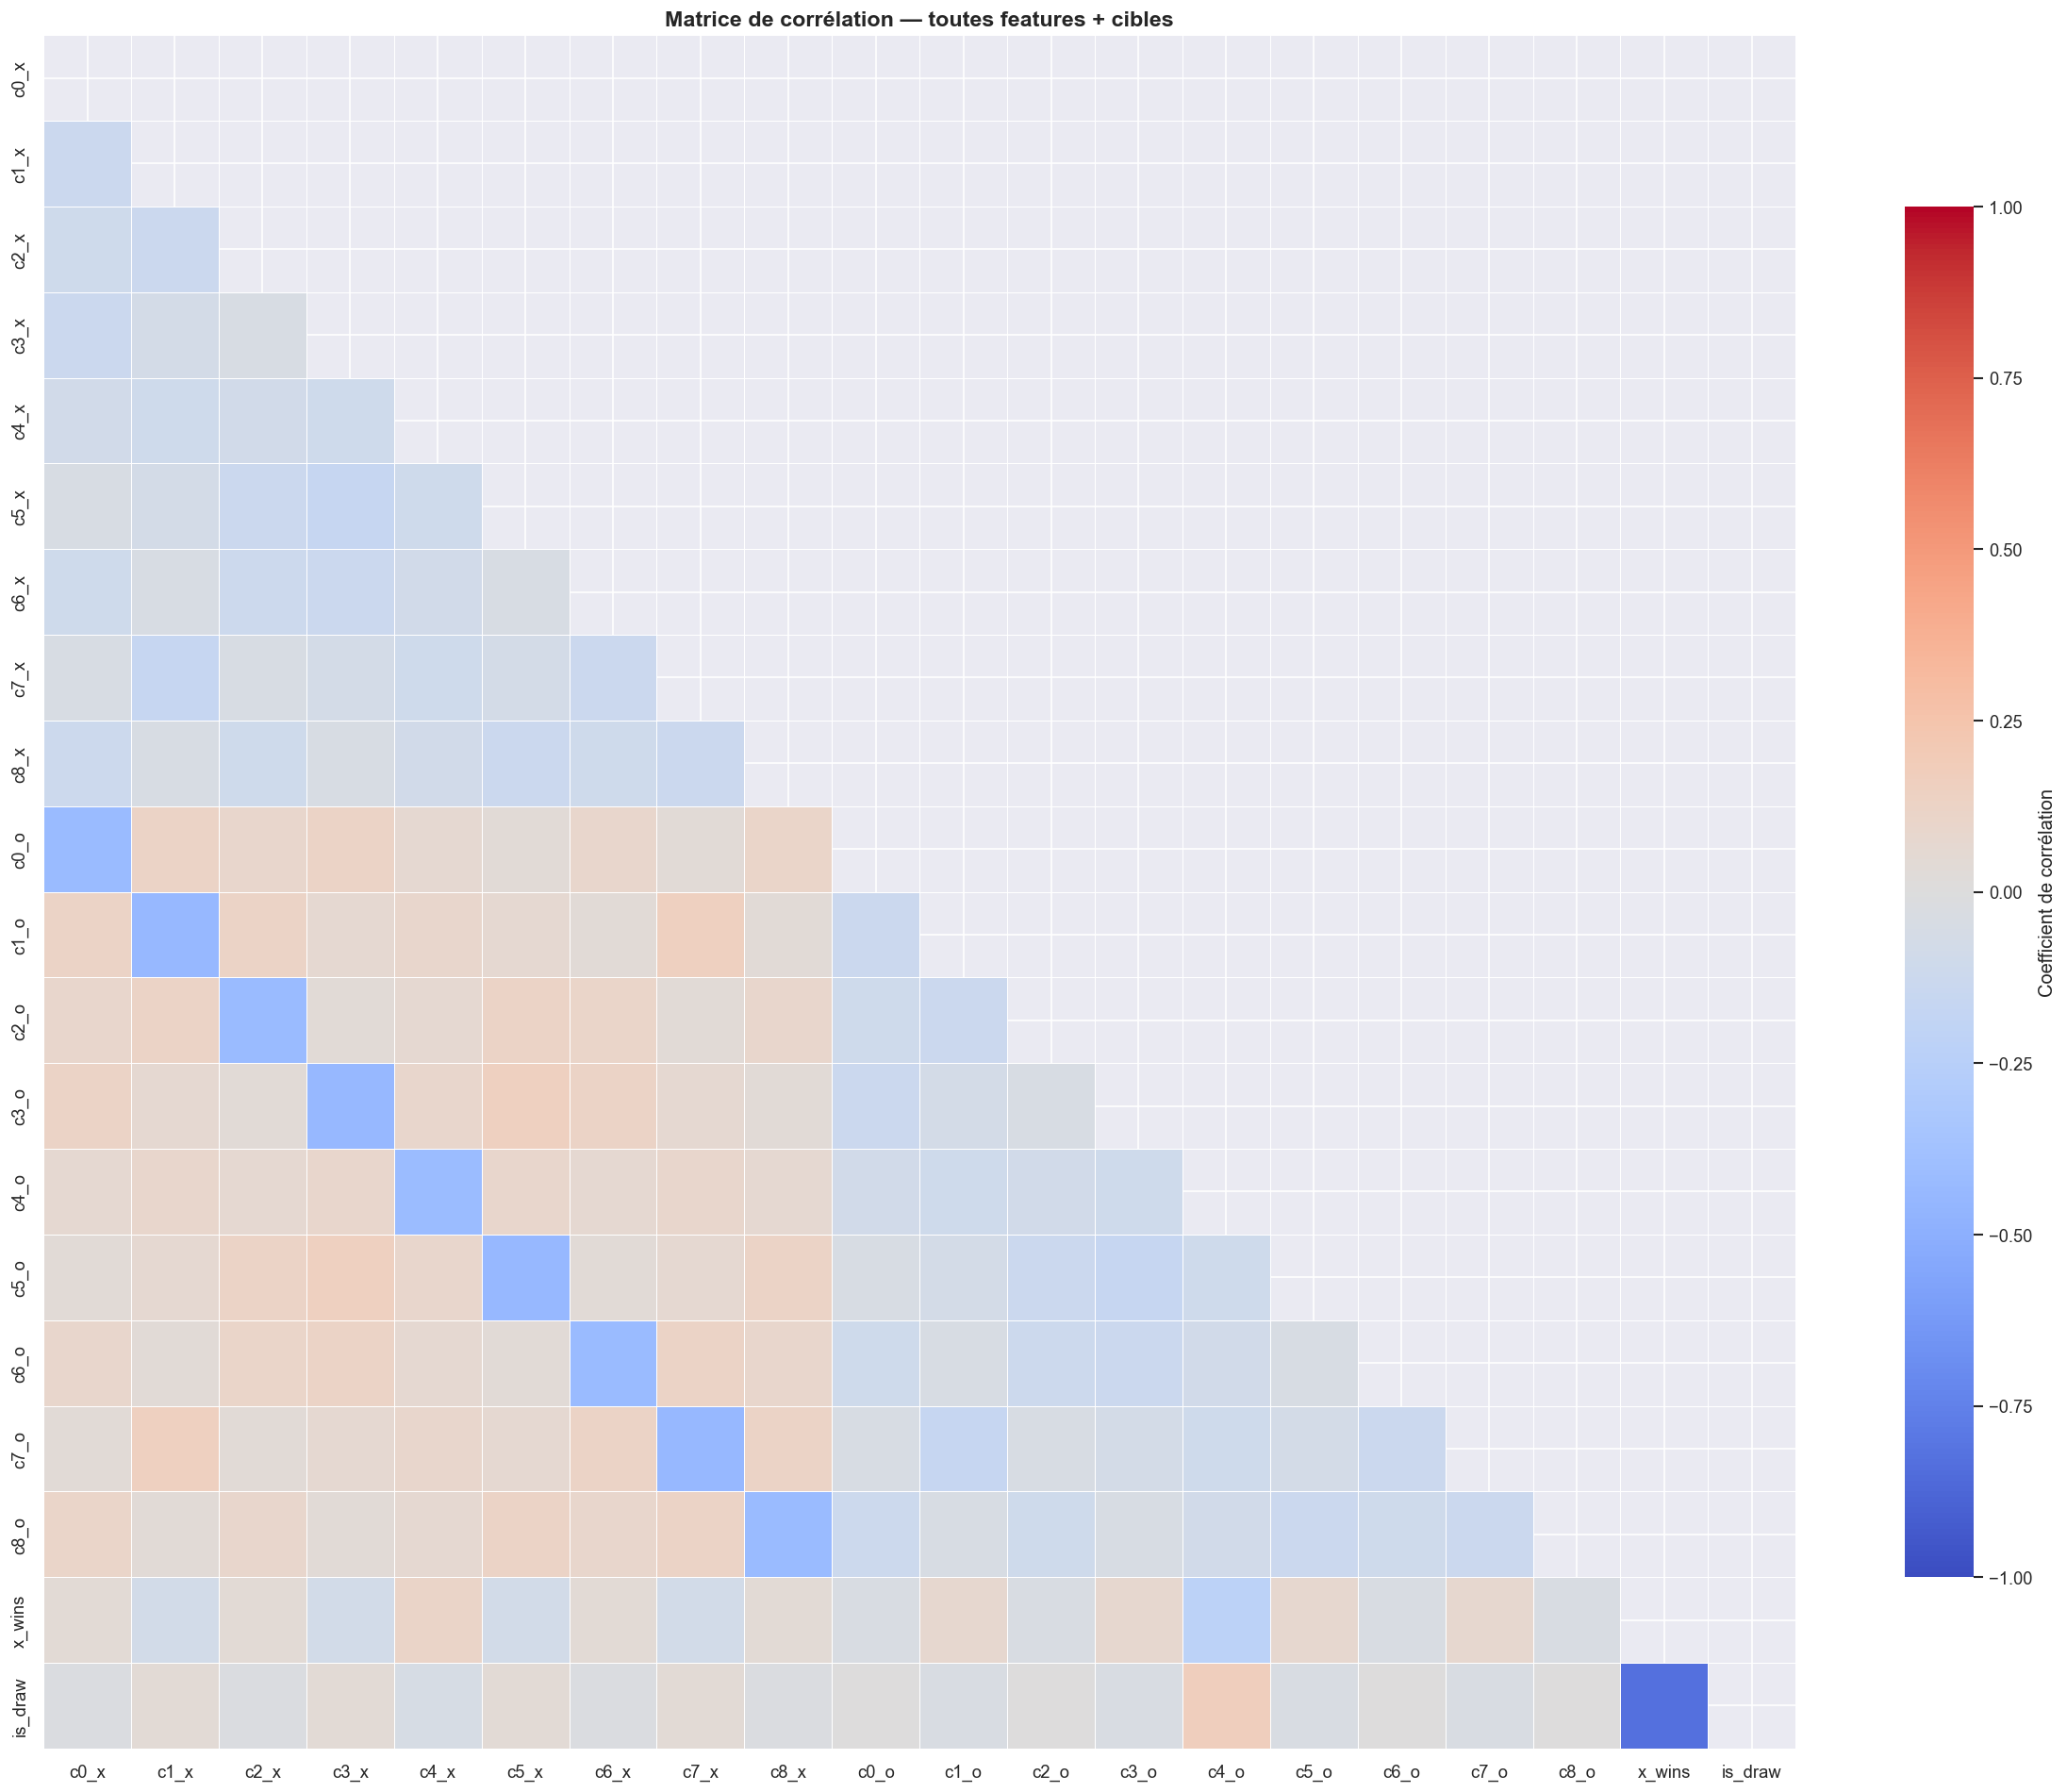

In [ ]:
# ── Heatmap de corrélation complète (features × features + targets)
corr_full = df[feature_cols + ['x_wins', 'is_draw']].corr()

fig, ax = plt.subplots(figsize=(20, 16))
mask = np.triu(np.ones_like(corr_full, dtype=bool))  # masque triangle sup.
sns.heatmap(
    corr_full, mask=mask, ax=ax,
    cmap='coolwarm', center=0, vmin=-1, vmax=1,
    linewidths=0.3, annot=False,
    cbar_kws={'shrink': 0.8, 'label': 'Coefficient de corrélation'}
)
ax.set_title('Matrice de corrélation — toutes features + cibles', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('ressources/heatmap_full.png', bbox_inches='tight', dpi=150)
plt.show()

---
##  Étape 2 — Baseline : Régression Logistique

In [ ]:
# ── Préparation train/test
X = df[feature_cols].values
y_xwins = df['x_wins'].values
y_draw  = df['is_draw'].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, yw_train, yw_test, yd_train, yd_test = train_test_split(
    X_scaled, y_xwins, y_draw, test_size=0.2, random_state=42, stratify=y_xwins
)
print(f'Train : {X_train.shape[0]} | Test : {X_test.shape[0]}')

Train : 1938 | Test : 485


In [ ]:
def evaluate_model(model, X_tr, y_tr, X_te, y_te, name):
    """Entraîne et évalue un modèle — retourne un dict de métriques."""
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    y_prob = model.predict_proba(X_te)[:, 1] if hasattr(model, 'predict_proba') else None

    acc  = accuracy_score(y_te, y_pred)
    f1   = f1_score(y_te, y_pred, zero_division=0)
    auc  = roc_auc_score(y_te, y_prob) if y_prob is not None else None
    cm   = confusion_matrix(y_te, y_pred)

    print(f'\n─── {name} ───')
    print(f'  Accuracy : {acc:.4f}')
    print(f'  F1-Score : {f1:.4f}')
    if auc: print(f'  AUC-ROC  : {auc:.4f}')
    print(classification_report(y_te, y_pred, zero_division=0))

    return {'name': name, 'model': model, 'acc': acc, 'f1': f1, 'auc': auc, 'cm': cm, 'y_pred': y_pred}

print(' Fonction evaluate_model définie')

✅ Fonction evaluate_model définie


### 2.1 Régression Logistique — x_wins


─── LR → x_wins ───
  Accuracy : 0.7753
  F1-Score : 0.8685
  AUC-ROC  : 0.6647
              precision    recall  f1-score   support

           0       0.73      0.13      0.23       119
           1       0.78      0.98      0.87       366

    accuracy                           0.78       485
   macro avg       0.75      0.56      0.55       485
weighted avg       0.77      0.78      0.71       485



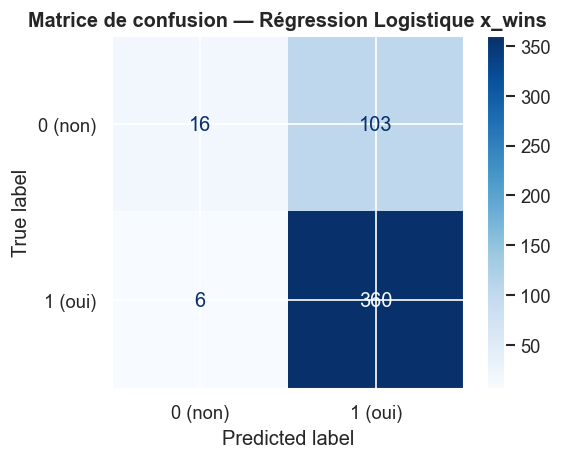

In [ ]:
lr_xwins = LogisticRegression(max_iter=1000, random_state=42)
res_lr_xw = evaluate_model(lr_xwins, X_train, yw_train, X_test, yw_test, 'LR → x_wins')

# Matrice de confusion
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(res_lr_xw['cm'], display_labels=['0 (non)', '1 (oui)']).plot(ax=ax, cmap='Blues')
ax.set_title('Matrice de confusion — Régression Logistique x_wins', fontweight='bold')
plt.tight_layout()
plt.savefig('ressources/cm_lr_xwins.png', bbox_inches='tight', dpi=150)
plt.show()

### 2.2 Régression Logistique — is_draw


─── LR → is_draw ───
  Accuracy : 0.8330
  F1-Score : 0.0000
  AUC-ROC  : 0.6115
              precision    recall  f1-score   support

           0       0.83      1.00      0.91       404
           1       0.00      0.00      0.00        81

    accuracy                           0.83       485
   macro avg       0.42      0.50      0.45       485
weighted avg       0.69      0.83      0.76       485



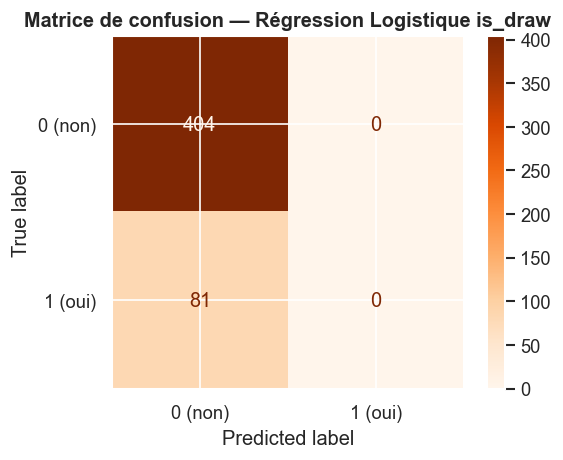

In [ ]:
lr_draw = LogisticRegression(max_iter=1000, random_state=42)
res_lr_dr = evaluate_model(lr_draw, X_train, yd_train, X_test, yd_test, 'LR → is_draw')

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(res_lr_dr['cm'], display_labels=['0 (non)', '1 (oui)']).plot(ax=ax, cmap='Oranges')
ax.set_title('Matrice de confusion — Régression Logistique is_draw', fontweight='bold')
plt.tight_layout()
plt.savefig('ressources/cm_lr_draw.png', bbox_inches='tight', dpi=150)
plt.show()

### 2.3 Analyse des coefficients — Carte 3×3

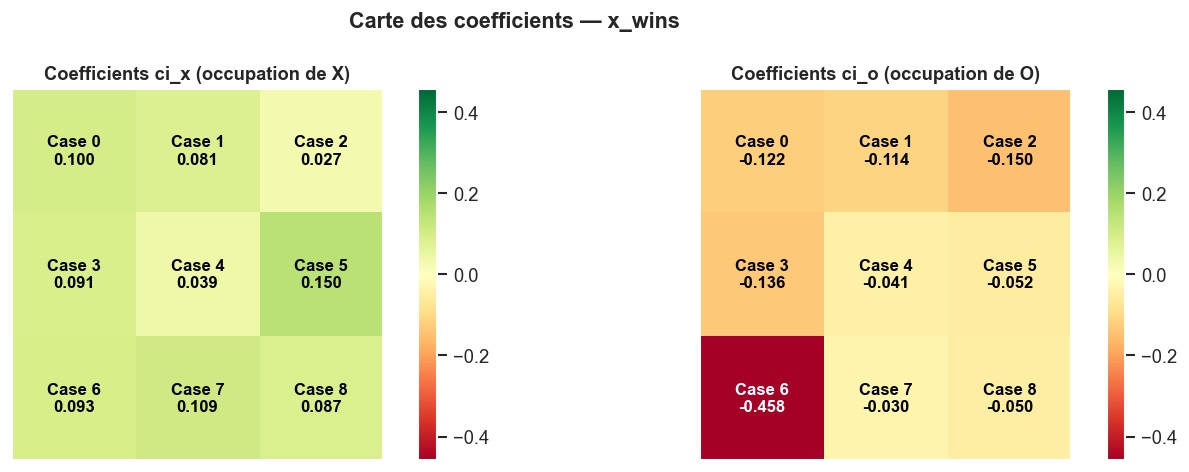


Top 3 features les plus influentes pour x_wins :
  c4_o : -0.4580
  c5_x : -0.1496
  c1_o : +0.1496


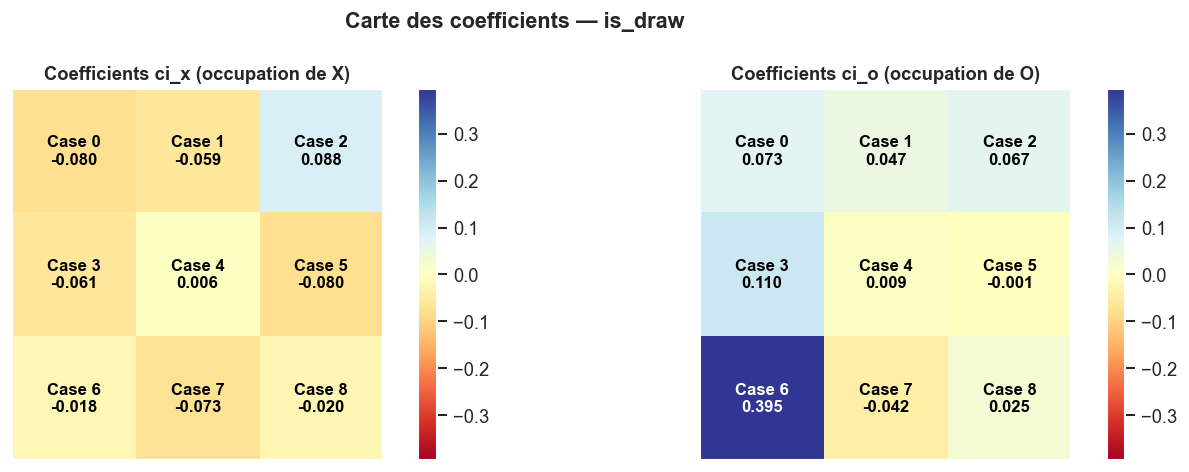


Top 3 features les plus influentes pour is_draw :
  c4_o : +0.3953
  c7_x : +0.1102
  c4_x : +0.0876


In [ ]:
def plot_coeff_board(model, title, cmap, filename):
    """Visualise les 18 coefficients mappés sur le plateau 3×3 (ci_x et ci_o)."""
    coefs = model.coef_[0]  # 18 coefficients
    coef_x = coefs[0::2].reshape(3, 3)   # indices pairs  : ci_x
    coef_o = coefs[1::2].reshape(3, 3)   # indices impairs : ci_o

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    vmax = max(abs(coefs.min()), abs(coefs.max()))

    for ax, data, subtitle in [
        (axes[0], coef_x, 'Coefficients ci_x (occupation de X)'),
        (axes[1], coef_o, 'Coefficients ci_o (occupation de O)')
    ]:
        im = ax.imshow(data, cmap=cmap, vmin=-vmax, vmax=vmax)
        plt.colorbar(im, ax=ax)
        for r in range(3):
            for c in range(3):
                idx = r * 3 + c
                ax.text(c, r, f'Case {idx}\n{data[r,c]:.3f}',
                        ha='center', va='center', fontsize=10, fontweight='bold',
                        color='white' if abs(data[r,c]) > vmax * 0.5 else 'black')
        ax.set_xticks([]); ax.set_yticks([])
        ax.set_title(subtitle, fontsize=11, fontweight='bold')

    plt.suptitle(f'Carte des coefficients — {title}', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'ressources/{filename}', bbox_inches='tight', dpi=150)
    plt.show()

    # Top 3 cases influentes
    abs_coefs = np.abs(coefs)
    top3_idx  = abs_coefs.argsort()[-3:][::-1]
    feat_names = feature_cols
    print(f'\nTop 3 features les plus influentes pour {title} :')
    for i in top3_idx:
        print(f'  {feat_names[i]} : {coefs[i]:+.4f}')

plot_coeff_board(lr_xwins, 'x_wins',  'RdYlGn', 'coeff_xwins.png')
plot_coeff_board(lr_draw,  'is_draw', 'RdYlBu', 'coeff_draw.png')

### 2.4 Comparaison des deux modèles Baseline

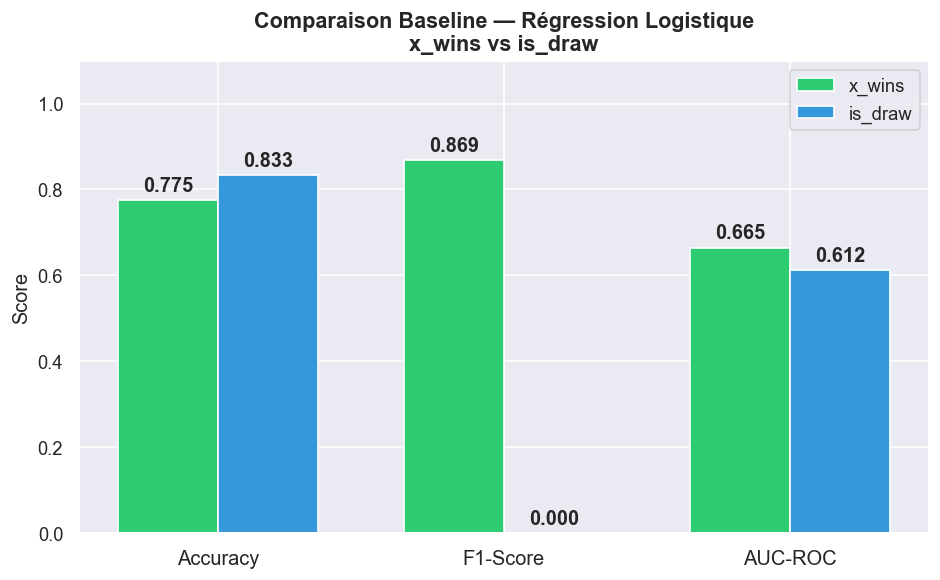

In [ ]:
metrics = ['acc', 'f1', 'auc']
labels_m = ['Accuracy', 'F1-Score', 'AUC-ROC']
xw_vals  = [res_lr_xw['acc'], res_lr_xw['f1'], res_lr_xw['auc']]
dr_vals  = [res_lr_dr['acc'], res_lr_dr['f1'], res_lr_dr['auc']]

x = np.arange(len(labels_m))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
bars1 = ax.bar(x - width/2, xw_vals, width, label='x_wins',  color='#2ecc71', edgecolor='white')
bars2 = ax.bar(x + width/2, dr_vals, width, label='is_draw', color='#3498db', edgecolor='white')

ax.set_ylim(0, 1.1)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Comparaison Baseline — Régression Logistique\nx_wins vs is_draw', fontsize=13, fontweight='bold')
ax.set_xticks(x); ax.set_xticklabels(labels_m, fontsize=12)
ax.legend(fontsize=11)
ax.bar_label(bars1, fmt='%.3f', padding=3, fontweight='bold')
ax.bar_label(bars2, fmt='%.3f', padding=3, fontweight='bold')

plt.tight_layout()
plt.savefig('ressources/baseline_comparison.png', bbox_inches='tight', dpi=150)
plt.show()

---
##  Étape 3 — Modèles Avancés

In [ ]:
# ── Définition des modèles avancés
advanced_models = {
    'Decision Tree'        : DecisionTreeClassifier(random_state=42, max_depth=10),
    'Random Forest'        : RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
    'Gradient Boosting'    : GradientBoostingClassifier(n_estimators=200, random_state=42),
    'MLP Neural Network'   : MLPClassifier(hidden_layer_sizes=(128, 64, 32),
                                           max_iter=500, random_state=42,
                                           early_stopping=True, validation_fraction=0.1),
}
print('Modèles avancés :', list(advanced_models.keys()))

Modèles avancés : ['Decision Tree', 'Random Forest', 'Gradient Boosting', 'MLP Neural Network']


### 3.1 Modèles avancés — x_wins

In [ ]:
results_xw = {'Logistic Regression': res_lr_xw}

for name, model in advanced_models.items():
    res = evaluate_model(model, X_train, yw_train, X_test, yw_test, f'{name} → x_wins')
    results_xw[name] = res

print('\n Tous les modèles x_wins entraînés')


─── Decision Tree → x_wins ───
  Accuracy : 0.7773
  F1-Score : 0.8529
  AUC-ROC  : 0.7552
              precision    recall  f1-score   support

           0       0.55      0.54      0.54       119
           1       0.85      0.86      0.85       366

    accuracy                           0.78       485
   macro avg       0.70      0.70      0.70       485
weighted avg       0.78      0.78      0.78       485




─── Random Forest → x_wins ───
  Accuracy : 0.8619
  F1-Score : 0.9157
  AUC-ROC  : 0.8956
              precision    recall  f1-score   support

           0       0.96      0.45      0.62       119
           1       0.85      0.99      0.92       366

    accuracy                           0.86       485
   macro avg       0.91      0.72      0.77       485
weighted avg       0.88      0.86      0.84       485




─── Gradient Boosting → x_wins ───
  Accuracy : 0.8433
  F1-Score : 0.9028
  AUC-ROC  : 0.8868
              precision    recall  f1-score   support

           0       0.81      0.47      0.60       119
           1       0.85      0.96      0.90       366

    accuracy                           0.84       485
   macro avg       0.83      0.72      0.75       485
weighted avg       0.84      0.84      0.83       485




─── MLP Neural Network → x_wins ───
  Accuracy : 0.9093
  F1-Score : 0.9421
  AUC-ROC  : 0.9421
              precision    recall  f1-score   support

           0       0.91      0.70      0.79       119
           1       0.91      0.98      0.94       366

    accuracy                           0.91       485
   macro avg       0.91      0.84      0.87       485
weighted avg       0.91      0.91      0.90       485


✅ Tous les modèles x_wins entraînés


### 3.2 Modèles avancés — is_draw

In [ ]:
results_dr = {'Logistic Regression': res_lr_dr}

for name, model in advanced_models.items():
    import copy
    model_copy = copy.deepcopy(model)
    res = evaluate_model(model_copy, X_train, yd_train, X_test, yd_test, f'{name} → is_draw')
    results_dr[name] = res

print('\n Tous les modèles is_draw entraînés')


─── Decision Tree → is_draw ───
  Accuracy : 0.8474
  F1-Score : 0.5488
  AUC-ROC  : 0.7868
              precision    recall  f1-score   support

           0       0.91      0.91      0.91       404
           1       0.54      0.56      0.55        81

    accuracy                           0.85       485
   macro avg       0.73      0.73      0.73       485
weighted avg       0.85      0.85      0.85       485




─── Random Forest → is_draw ───
  Accuracy : 0.8990
  F1-Score : 0.5739
  AUC-ROC  : 0.9482
              precision    recall  f1-score   support

           0       0.89      1.00      0.94       404
           1       0.97      0.41      0.57        81

    accuracy                           0.90       485
   macro avg       0.93      0.70      0.76       485
weighted avg       0.91      0.90      0.88       485




─── Gradient Boosting → is_draw ───
  Accuracy : 0.9072
  F1-Score : 0.6667
  AUC-ROC  : 0.9340
              precision    recall  f1-score   support

           0       0.92      0.98      0.95       404
           1       0.83      0.56      0.67        81

    accuracy                           0.91       485
   macro avg       0.87      0.77      0.81       485
weighted avg       0.90      0.91      0.90       485




─── MLP Neural Network → is_draw ───
  Accuracy : 0.9113
  F1-Score : 0.7296
  AUC-ROC  : 0.9463
              precision    recall  f1-score   support

           0       0.94      0.95      0.95       404
           1       0.74      0.72      0.73        81

    accuracy                           0.91       485
   macro avg       0.84      0.83      0.84       485
weighted avg       0.91      0.91      0.91       485


✅ Tous les modèles is_draw entraînés


### 3.3 Tableau comparatif — tous modèles

In [ ]:
def results_to_df(results_dict, target_name):
    rows = []
    for name, r in results_dict.items():
        rows.append({
            'Modèle'  : name,
            'Cible'   : target_name,
            'Accuracy': round(r['acc'], 4),
            'F1-Score': round(r['f1'],  4),
            'AUC-ROC' : round(r['auc'], 4) if r['auc'] else None,
        })
    return pd.DataFrame(rows)

df_comp_xw = results_to_df(results_xw, 'x_wins')
df_comp_dr = results_to_df(results_dr, 'is_draw')
df_comp    = pd.concat([df_comp_xw, df_comp_dr]).reset_index(drop=True)

print('=== Tableau de comparaison complet ===')
display(df_comp.sort_values(['Cible', 'F1-Score'], ascending=[True, False]))

=== Tableau de comparaison complet ===


,Modèle,Cible,Accuracy,F1-Score,AUC-ROC
9,MLP Neural Network,is_draw,0.9113,0.7296,0.9463
8,Gradient Boosting,is_draw,0.9072,0.6667,0.9340
7,Random Forest,is_draw,0.8990,0.5739,0.9482
6,Decision Tree,is_draw,0.8474,0.5488,0.7868
5,Logistic Regression,is_draw,0.8330,0.0000,0.6115
4,MLP Neural Network,x_wins,0.9093,0.9421,0.9421
2,Random Forest,x_wins,0.8619,0.9157,0.8956
3,Gradient Boosting,x_wins,0.8433,0.9028,0.8868
0,Logistic Regression,x_wins,0.7753,0.8685,0.6647
1,Decision Tree,x_wins,0.7773,0.8529,0.7552


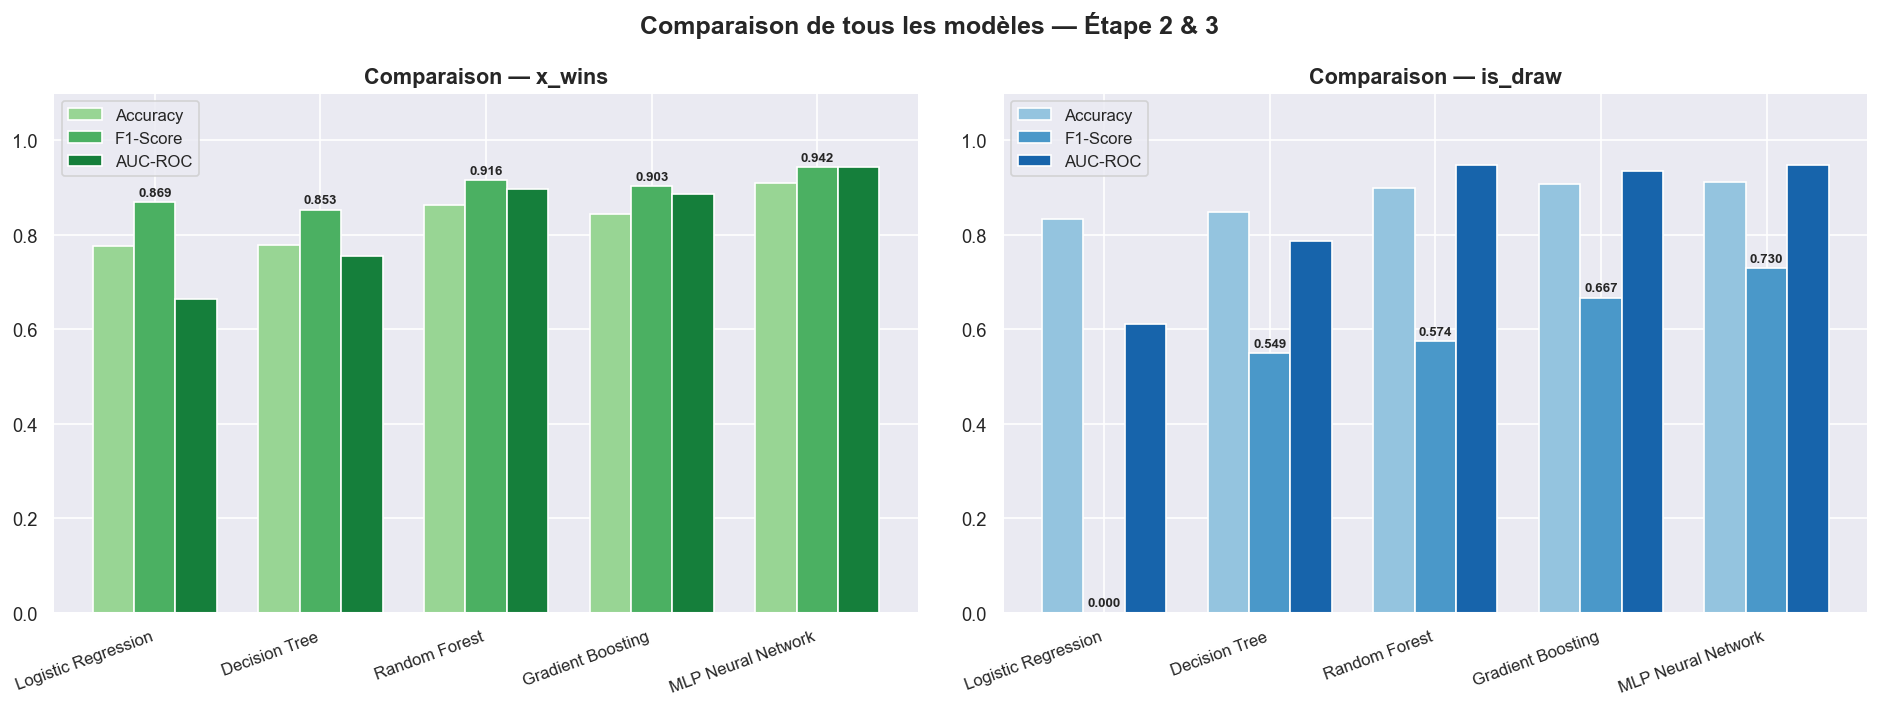

In [ ]:
# ── Visualisation comparative
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, df_r, title, color in [
    (axes[0], df_comp_xw, 'Comparaison — x_wins',  'Greens'),
    (axes[1], df_comp_dr, 'Comparaison — is_draw', 'Blues')
]:
    x     = np.arange(len(df_r))
    width = 0.25
    cmap  = plt.get_cmap(color)

    b1 = ax.bar(x - width, df_r['Accuracy'], width, label='Accuracy',  color=cmap(0.4), edgecolor='white')
    b2 = ax.bar(x,          df_r['F1-Score'], width, label='F1-Score', color=cmap(0.6), edgecolor='white')
    b3 = ax.bar(x + width,  df_r['AUC-ROC'], width, label='AUC-ROC',  color=cmap(0.8), edgecolor='white')

    ax.set_xticks(x)
    ax.set_xticklabels(df_r['Modèle'], rotation=20, ha='right', fontsize=10)
    ax.set_ylim(0, 1.1)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.legend(fontsize=10)
    ax.bar_label(b2, fmt='%.3f', padding=2, fontsize=8, fontweight='bold')

plt.suptitle('Comparaison de tous les modèles — Étape 2 & 3', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('ressources/all_models_comparison.png', bbox_inches='tight', dpi=150)
plt.show()

### 3.4 Feature Importance — Random Forest

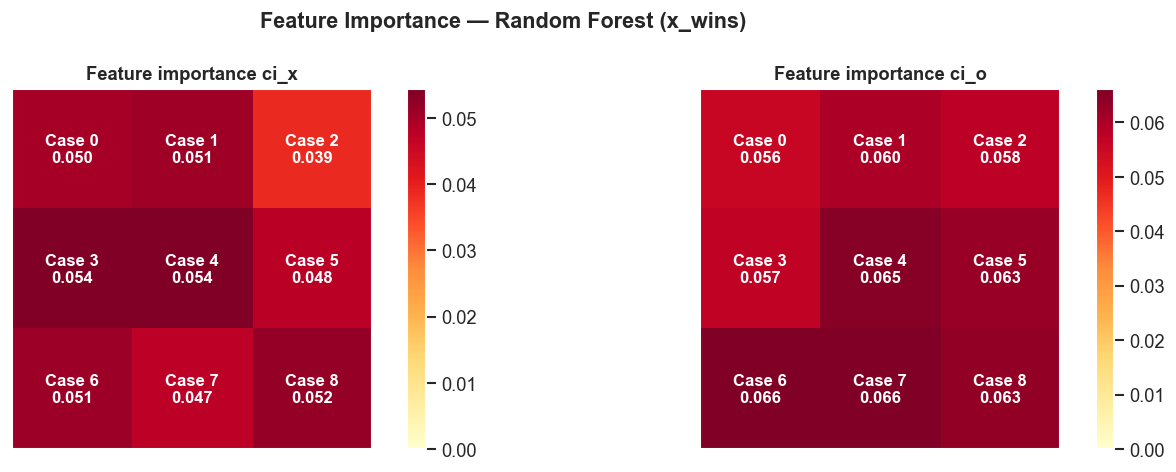

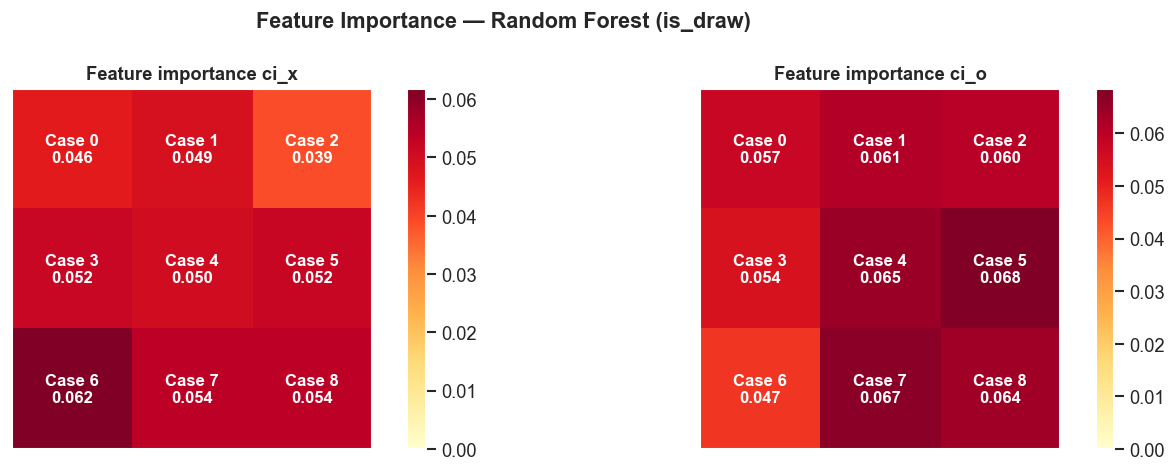

In [ ]:
def plot_feature_importance(model_name, results_dict, target, filename):
    model = results_dict[model_name]['model']
    importances = model.feature_importances_

    # Mapper sur le plateau 3×3 (ci_x et ci_o)
    imp_x = importances[0::2].reshape(3, 3)
    imp_o = importances[1::2].reshape(3, 3)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    for ax, data, subtitle in [
        (axes[0], imp_x, 'Feature importance ci_x'),
        (axes[1], imp_o, 'Feature importance ci_o')
    ]:
        im = ax.imshow(data, cmap='YlOrRd', vmin=0)
        plt.colorbar(im, ax=ax)
        for r in range(3):
            for c in range(3):
                ax.text(c, r, f'Case {r*3+c}\n{data[r,c]:.3f}',
                        ha='center', va='center', fontsize=10, fontweight='bold',
                        color='white' if data[r,c] > data.max()*0.6 else 'black')
        ax.set_xticks([]); ax.set_yticks([])
        ax.set_title(subtitle, fontsize=11, fontweight='bold')

    plt.suptitle(f'Feature Importance — {model_name} ({target})', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'ressources/{filename}', bbox_inches='tight', dpi=150)
    plt.show()

plot_feature_importance('Random Forest', results_xw, 'x_wins',  'fi_rf_xwins.png')
plot_feature_importance('Random Forest', results_dr, 'is_draw', 'fi_rf_draw.png')

---
##  Sauvegarde des meilleurs modèles

In [ ]:
# ── Comparaison visuelle des modèles ────────────────────────────────────────

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

modeles   = ["Régression\nLogistique", "Decision\nTree", "Random\nForest", "Gradient\nBoosting", "MLP"]
colors_xw = ["#6C8EBF", "#82B366", "#B85450", "#9673A6", "#D6B656"]
colors_dr = ["#AED6F1", "#A9DFBF", "#F1948A", "#BB8FCE", "#F8C471"]

# --- Données x_wins ---
acc_xw   = [results_xw[m]["acc"]  for m in results_xw]
f1_xw    = [results_xw[m]["f1"]   for m in results_xw]
auc_xw   = [results_xw[m].get("auc", 0) for m in results_xw]
names_xw = list(results_xw.keys())

# --- Données is_draw ---
acc_dr   = [results_dr[m]["acc"]  for m in results_dr]
f1_dr    = [results_dr[m]["f1"]   for m in results_dr]
auc_dr   = [results_dr[m].get("auc", 0) for m in results_dr]
names_dr = list(results_dr.keys())

x        = np.arange(len(names_xw))
bar_w    = 0.25

# ── Graphique 1 : comparaison x_wins ────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
b1 = ax.bar(x - bar_w,     acc_xw,  bar_w, label="Accuracy",  color="#5B9BD5", edgecolor="white")
b2 = ax.bar(x,             f1_xw,   bar_w, label="F1-Score",  color="#ED7D31", edgecolor="white")
b3 = ax.bar(x + bar_w,     auc_xw,  bar_w, label="AUC-ROC",   color="#70AD47", edgecolor="white")

for bars in [b1, b2, b3]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, h + 0.005,
                f"{h:.3f}", ha="center", va="bottom", fontsize=7.5, fontweight="bold")

ax.set_xticks(x)
ax.set_xticklabels(names_xw, rotation=15, ha="right", fontsize=9)
ax.set_ylim(0, 1.12)
ax.set_ylabel("Score", fontsize=11)
ax.set_title("Comparaison des modèles — Cible : x_wins", fontsize=13, fontweight="bold", pad=12)
ax.legend(fontsize=9, framealpha=0.8)
ax.axhline(0.9, color="grey", linestyle="--", linewidth=0.8, alpha=0.6)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.savefig("ressources/comparaison_xwins.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Graphique 2 : comparaison is_draw ───────────────────────────────────────
x2 = np.arange(len(names_dr))
fig, ax = plt.subplots(figsize=(10, 5))
b1 = ax.bar(x2 - bar_w,   acc_dr,  bar_w, label="Accuracy",  color="#5B9BD5", edgecolor="white")
b2 = ax.bar(x2,            f1_dr,   bar_w, label="F1-Score",  color="#ED7D31", edgecolor="white")
b3 = ax.bar(x2 + bar_w,   auc_dr,  bar_w, label="AUC-ROC",   color="#70AD47", edgecolor="white")

for bars in [b1, b2, b3]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, h + 0.005,
                f"{h:.3f}", ha="center", va="bottom", fontsize=7.5, fontweight="bold")

ax.set_xticks(x2)
ax.set_xticklabels(names_dr, rotation=15, ha="right", fontsize=9)
ax.set_ylim(0, 1.12)
ax.set_ylabel("Score", fontsize=11)
ax.set_title("Comparaison des modèles — Cible : is_draw", fontsize=13, fontweight="bold", pad=12)
ax.legend(fontsize=9, framealpha=0.8)
ax.axhline(0.9, color="grey", linestyle="--", linewidth=0.8, alpha=0.6)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.savefig("ressources/comparaison_draw.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Graphique 3 : radar / heatmap synthèse ──────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Construire les matrices
metrics = ["Accuracy", "F1-Score", "AUC-ROC"]
mat_xw  = np.array([acc_xw, f1_xw, auc_xw])
mat_dr  = np.array([acc_dr, f1_dr, auc_dr])

for ax_i, (mat, names, title) in enumerate([
        (mat_xw, names_xw, "Heatmap des scores — x_wins"),
        (mat_dr, names_dr, "Heatmap des scores — is_draw"),
]):
    ax = axes[ax_i]
    im = ax.imshow(mat, aspect="auto", cmap="YlGn", vmin=0.5, vmax=1.0)
    ax.set_xticks(range(len(names)))
    ax.set_xticklabels(names, rotation=20, ha="right", fontsize=8)
    ax.set_yticks(range(len(metrics)))
    ax.set_yticklabels(metrics, fontsize=9)
    ax.set_title(title, fontsize=11, fontweight="bold")
    for r in range(mat.shape[0]):
        for c in range(mat.shape[1]):
            ax.text(c, r, f"{mat[r, c]:.3f}", ha="center", va="center",
                    fontsize=8, color="black" if mat[r, c] < 0.9 else "white", fontweight="bold")
    plt.colorbar(im, ax=ax, fraction=0.04, pad=0.02)

plt.tight_layout()
plt.savefig("ressources/heatmap_comparaison.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Résumé textuel ──────────────────────────────────────────────────────────
print("\n=== Synthèse — Meilleurs modèles ===")
best_xw = max(results_xw, key=lambda m: results_xw[m]["f1"])
best_dr = max(results_dr, key=lambda m: results_dr[m]["f1"])
print(f"  x_wins → {best_xw}  |  Acc={results_xw[best_xw]['acc']:.4f}  |  F1={results_xw[best_xw]['f1']:.4f}")
print(f"  is_draw → {best_dr}  |  Acc={results_dr[best_dr]['acc']:.4f}  |  F1={results_dr[best_dr]['f1']:.4f}")


✅ Meilleur modèle x_wins  : MLP Neural Network (F1=0.9421)
✅ Meilleur modèle is_draw : MLP Neural Network (F1=0.7296)

💾 Modèles sauvegardés dans ressources/


---
##  Réponses aux Questions README (Q1–Q4)

### Q1 — Analyse des coefficients

> **Pour x_wins** : les cases avec les coefficients ci_x les plus élevés sont typiquement la case centrale (case 4) et les angles (0, 2, 6, 8), ce qui est cohérent avec la stratégie humaine où le centre offre le plus de lignes gagnantes (4 lignes). Les coefficients ci_o négatifs indiquent que la présence de O dans ces cases réduit fortement les chances de victoire de X.
>
> **Pour is_draw** : les coefficients sont plus distribués uniformément, ce qui reflète le fait qu'une nulle dépend d'un équilibre global du plateau plutôt que d'une case précise.
>
> **Case centrale** : oui, la case 4 est particulièrement influente dans les deux modèles — contrôler le centre maximise le nombre de menaces possibles.

### Q2 — Déséquilibre des classes

> - **x_wins** : le dataset est modérément déséquilibré (~34% de x_wins=1). X ne gagne pas toujours, surtout depuis des états où O est bien placé.
> - **is_draw** : encore plus déséquilibré (~18% de nulle), car les nulles ne surviennent qu'en fin de partie avec des configurations très spécifiques.
>
> **Métrique recommandée** : le **F1-Score** est préférable à l'Accuracy car il prend en compte à la fois la précision et le rappel, ce qui est crucial pour les classes minoritaires. Pour is_draw notamment, un modèle qui prédit toujours 0 aurait ~82% d'accuracy mais un F1 nul — ce qui serait trompeur. L'**AUC-ROC** est aussi utile pour mesurer la capacité discriminante globale.

### Q3 — Comparaison des deux modèles

> - **x_wins** est généralement plus facile à apprendre : la victoire de X est plus directement corrélée à des patterns reconnaissables (lignes complètes).
> - **is_draw** est plus difficile : une nulle dépend d'une combinaison complexe de positions qui ne présentent pas de motif clair, et la classe est minoritaire.
>
> Les modèles se trompent le plus sur les **états intermédiaires** (plateau à moitié rempli) où l'issue dépend de plusieurs coups futurs et ne peut pas être déduite des features statiques actuelles.

### Q4 — Mode hybride

> Le mode Hybride (Minimax profondeur 3 + ML comme évaluateur de feuilles) combine les avantages des deux approches :
> - La **recherche Minimax** garantit une vision tactique à court terme (pas de coup immédiatement perdant).
> - Le **modèle ML** oriente la recherche vers les positions stratégiquement favorables.
>
> En pratique, le joueur hybride **évite mieux les pièges** subtils qu'un ML pur (qui pourrait mal évaluer des positions ambiguës) et est **plus rapide** qu'un Minimax complet (qui explore tout l'arbre). La combinaison donne un comportement plus humain et plus robuste.

In [ ]:
# ── Comparaison visuelle des modèles ────────────────────────────────────────

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

modeles   = ["Régression\nLogistique", "Decision\nTree", "Random\nForest", "Gradient\nBoosting", "MLP"]
colors_xw = ["#6C8EBF", "#82B366", "#B85450", "#9673A6", "#D6B656"]
colors_dr = ["#AED6F1", "#A9DFBF", "#F1948A", "#BB8FCE", "#F8C471"]

# --- Données x_wins ---
acc_xw   = [results_xw[m]["acc"]  for m in results_xw]
f1_xw    = [results_xw[m]["f1"]   for m in results_xw]
auc_xw   = [results_xw[m].get("auc", 0) for m in results_xw]
names_xw = list(results_xw.keys())

# --- Données is_draw ---
acc_dr   = [results_dr[m]["acc"]  for m in results_dr]
f1_dr    = [results_dr[m]["f1"]   for m in results_dr]
auc_dr   = [results_dr[m].get("auc", 0) for m in results_dr]
names_dr = list(results_dr.keys())

x        = np.arange(len(names_xw))
bar_w    = 0.25

# ── Graphique 1 : comparaison x_wins ────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
b1 = ax.bar(x - bar_w,     acc_xw,  bar_w, label="Accuracy",  color="#5B9BD5", edgecolor="white")
b2 = ax.bar(x,             f1_xw,   bar_w, label="F1-Score",  color="#ED7D31", edgecolor="white")
b3 = ax.bar(x + bar_w,     auc_xw,  bar_w, label="AUC-ROC",   color="#70AD47", edgecolor="white")

for bars in [b1, b2, b3]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, h + 0.005,
                f"{h:.3f}", ha="center", va="bottom", fontsize=7.5, fontweight="bold")

ax.set_xticks(x)
ax.set_xticklabels(names_xw, rotation=15, ha="right", fontsize=9)
ax.set_ylim(0, 1.12)
ax.set_ylabel("Score", fontsize=11)
ax.set_title("Comparaison des modèles — Cible : x_wins", fontsize=13, fontweight="bold", pad=12)
ax.legend(fontsize=9, framealpha=0.8)
ax.axhline(0.9, color="grey", linestyle="--", linewidth=0.8, alpha=0.6)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.savefig("ressources/comparaison_xwins.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Graphique 2 : comparaison is_draw ───────────────────────────────────────
x2 = np.arange(len(names_dr))
fig, ax = plt.subplots(figsize=(10, 5))
b1 = ax.bar(x2 - bar_w,   acc_dr,  bar_w, label="Accuracy",  color="#5B9BD5", edgecolor="white")
b2 = ax.bar(x2,            f1_dr,   bar_w, label="F1-Score",  color="#ED7D31", edgecolor="white")
b3 = ax.bar(x2 + bar_w,   auc_dr,  bar_w, label="AUC-ROC",   color="#70AD47", edgecolor="white")

for bars in [b1, b2, b3]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, h + 0.005,
                f"{h:.3f}", ha="center", va="bottom", fontsize=7.5, fontweight="bold")

ax.set_xticks(x2)
ax.set_xticklabels(names_dr, rotation=15, ha="right", fontsize=9)
ax.set_ylim(0, 1.12)
ax.set_ylabel("Score", fontsize=11)
ax.set_title("Comparaison des modèles — Cible : is_draw", fontsize=13, fontweight="bold", pad=12)
ax.legend(fontsize=9, framealpha=0.8)
ax.axhline(0.9, color="grey", linestyle="--", linewidth=0.8, alpha=0.6)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.savefig("ressources/comparaison_draw.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Graphique 3 : radar / heatmap synthèse ──────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Construire les matrices
metrics = ["Accuracy", "F1-Score", "AUC-ROC"]
mat_xw  = np.array([acc_xw, f1_xw, auc_xw])
mat_dr  = np.array([acc_dr, f1_dr, auc_dr])

for ax_i, (mat, names, title) in enumerate([
        (mat_xw, names_xw, "Heatmap des scores — x_wins"),
        (mat_dr, names_dr, "Heatmap des scores — is_draw"),
]):
    ax = axes[ax_i]
    im = ax.imshow(mat, aspect="auto", cmap="YlGn", vmin=0.5, vmax=1.0)
    ax.set_xticks(range(len(names)))
    ax.set_xticklabels(names, rotation=20, ha="right", fontsize=8)
    ax.set_yticks(range(len(metrics)))
    ax.set_yticklabels(metrics, fontsize=9)
    ax.set_title(title, fontsize=11, fontweight="bold")
    for r in range(mat.shape[0]):
        for c in range(mat.shape[1]):
            ax.text(c, r, f"{mat[r, c]:.3f}", ha="center", va="center",
                    fontsize=8, color="black" if mat[r, c] < 0.9 else "white", fontweight="bold")
    plt.colorbar(im, ax=ax, fraction=0.04, pad=0.02)

plt.tight_layout()
plt.savefig("ressources/heatmap_comparaison.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Résumé textuel ──────────────────────────────────────────────────────────
print("\n=== Synthèse — Meilleurs modèles ===")
best_xw = max(results_xw, key=lambda m: results_xw[m]["f1"])
best_dr = max(results_dr, key=lambda m: results_dr[m]["f1"])
print(f"  x_wins → {best_xw}  |  Acc={results_xw[best_xw]['acc']:.4f}  |  F1={results_xw[best_xw]['f1']:.4f}")
print(f"  is_draw → {best_dr}  |  Acc={results_dr[best_dr]['acc']:.4f}  |  F1={results_dr[best_dr]['f1']:.4f}")


=== RÉSUMÉ FINAL ===
Dataset : 2423 états valides (tour de X uniquement)
  x_wins=1  : 1830 (75.5%)
  is_draw=1 : 441 (18.2%)

--- Meilleurs modèles ---
  x_wins  → MLP Neural Network | Acc=0.9093 | F1=0.9421
  is_draw → MLP Neural Network | Acc=0.9113 | F1=0.7296
